# SHAP and LIME: Local Model Explainability

Modern predictive models — gradient-boosted trees, random forests, neural
networks — are accurate but opaque: a single prediction is the output of
thousands of internal decision boundaries, and no one, including the model's
author, can read off "why" from the weights directly. **Local
explainability** methods answer a narrower, more tractable question than
"explain the whole model": *for this one prediction, on this one input, how
much did each feature contribute?*

This tutorial builds up the two dominant local explanation methods from
first principles:

- **SHAP** (SHapley Additive exPlanations, Lundberg & Lee 2017) — grounds
  feature attribution in **Shapley values** from cooperative game theory,
  giving attributions that provably satisfy a specific set of fairness-like
  axioms.
- **LIME** (Local Interpretable Model-agnostic Explanations, Ribeiro,
  Singh & Guestrin 2016) — fits a simple, interpretable surrogate model in
  the local neighborhood of one prediction and reads feature importance off
  the surrogate.

We'll derive the Shapley value formula and its four defining axioms, derive
LIME's optimization objective, formally compare what each method does and
does not guarantee, and then apply both real libraries (`shap`, `lime`) to
a gradient-boosted-tree model trained on the real UCI **Adult / Census
Income** dataset — a canonical high-stakes use case (would this person's
predicted income class change if one feature were different, and is that a
legitimate or a discriminatory reason?).

By the end you'll be able to: derive why Shapley values are the *unique*
attribution satisfying efficiency, symmetry, dummy, and additivity; explain
what KernelSHAP and TreeSHAP actually compute and why TreeSHAP is exact
while KernelSHAP is an approximation; write out LIME's fidelity+complexity
objective and explain what its hyperparameters control; and — critically —
explain *why* SHAP and LIME can disagree on the same prediction, and why
neither one should be over-trusted as a global explanation of the model.

## 1. Theory

### 1.1 Setup and notation

Let $f: \mathbb{R}^d \to \mathbb{R}$ be a trained "black-box" model (e.g. a
probability output of a classifier), and let $x = (x_1, \dots, x_d)$ be one
specific input instance we want to explain — the prediction $f(x)$. A
**local explanation** is a method that attributes $f(x)$ to the $d$
features, producing an attribution vector $\phi = (\phi_1, \dots, \phi_d)$
where $\phi_i$ is "how much feature $i$ contributed to this particular
prediction," relative to some baseline.

Both SHAP and LIME belong to a family Lundberg & Lee call **additive
feature attribution methods**: they explain $f(x)$ with a simpler
interpretable model $g$ operating on a binary "presence/absence" vector
$z' \in \{0,1\}^d$ (1 = feature present, 0 = feature absent/replaced by a
baseline), such that

$$g(z') = \phi_0 + \sum_{i=1}^{d} \phi_i z_i', \qquad g(x') \approx f(x)$$

where $x'$ is the all-ones vector (all features present) and $\phi_0$ is
the explanation's baseline value. Every method below is a different way of
choosing the $\phi_i$'s.

### 1.2 Shapley values from cooperative game theory

SHAP's attributions come from a 70-year-old result in cooperative game
theory, not from machine learning. Consider a **coalitional game**: a set
of $d$ "players" $N = \{1, \dots, d\}$ and a **value function**
$v: 2^N \to \mathbb{R}$ that assigns a payoff $v(S)$ to every possible
coalition (subset) $S \subseteq N$ of players who "cooperate," with
$v(\emptyset) = 0$. The question Shapley (1953) answered: **how should the
total payoff $v(N)$ be fairly split among the $d$ players**, accounting for
each player's marginal contribution across every possible order they could
join the coalition?

**The Shapley value.** Player $i$'s fair share is the *average marginal
contribution* of $i$ over all possible coalitions that could have formed
before $i$ joined, weighted by how many orderings produce each coalition:

$$\phi_i(v) = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! \, (d - |S| - 1)!}{d!} \Big[ v(S \cup \{i\}) - v(S) \Big]$$

Read the weight $\frac{|S|!(d-|S|-1)!}{d!}$ as: out of the $d!$ possible
orderings in which all $d$ players could arrive one at a time, this is the
fraction of orderings in which exactly the players in $S$ arrive before $i$
(there are $|S|!$ ways to order $S$ before $i$, and $(d-|S|-1)!$ ways to
order the rest after $i$). An equivalent, often more intuitive form
averages the marginal contribution $v(P_i^\pi \cup \{i\}) - v(P_i^\pi)$
over all $d!$ permutations $\pi$ of $N$, where $P_i^\pi$ is the set of
players preceding $i$ in permutation $\pi$:

$$\phi_i(v) = \frac{1}{d!} \sum_{\pi \in \Pi(N)} \Big[ v(P_i^\pi \cup \{i\}) - v(P_i^\pi) \Big]$$

**Why this specific formula, and not some other averaging scheme?** Shapley
proved it is the *unique* value split satisfying four natural fairness
axioms simultaneously:

1. **Efficiency.** The attributions exactly sum to the total payoff:
   $\sum_{i=1}^d \phi_i(v) = v(N) - v(\emptyset)$. Nothing is left
   unallocated and nothing is invented.
2. **Symmetry.** If two players $i, j$ contribute identically to every
   coalition that excludes both of them — i.e.
   $v(S \cup \{i\}) = v(S \cup \{j\})$ for all $S \subseteq N \setminus
   \{i,j\}$ — then $\phi_i(v) = \phi_j(v)$. Interchangeable players get
   identical credit.
3. **Dummy (null player).** If a player contributes nothing to any
   coalition — $v(S \cup \{i\}) = v(S)$ for all $S$ — then $\phi_i(v) = 0$.
   A feature that never changes the outcome gets zero attribution.
4. **Additivity (linearity).** For two games $v$ and $w$ played over the
   same players, the Shapley value of the combined game $v + w$ equals the
   sum of the individual Shapley values: $\phi_i(v + w) = \phi_i(v) +
   \phi_i(w)$. This lets attributions compose across, e.g., an ensemble of
   models (the Shapley value of an averaged ensemble is the average of the
   per-model Shapley values).

This uniqueness result is the entire reason SHAP is theoretically special
among attribution methods: it is not "a reasonable heuristic," it is *the
only* attribution rule consistent with these four properties, once you fix
what the "game" $v$ is.

### 1.3 SHAP: turning a prediction into a coalitional game

To use Shapley values for feature attribution, SHAP defines the value
function $v$ so that "players" are input features and $v(S)$ is the
model's expected output when only the features in $S$ are known (the rest
are treated as missing / marginalized out over the data distribution):

$$v(S) = \mathbb{E}\big[f(X) \mid X_S = x_S\big]$$

Plugging this $v$ into the Shapley formula gives the **SHAP value** of
feature $i$ for instance $x$:

$$\phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! \, (d - |S| - 1)!}{d!} \Big[ \mathbb{E}[f(X) \mid X_{S \cup \{i\}} = x_{S \cup \{i\}}] - \mathbb{E}[f(X) \mid X_S = x_S] \Big]$$

By the efficiency axiom, these satisfy **local accuracy**:

$$f(x) = \phi_0 + \sum_{i=1}^{d} \phi_i, \qquad \phi_0 = \mathbb{E}[f(X)]$$

i.e. the prediction is *exactly* decomposed into a baseline (the average
model output) plus each feature's signed contribution — nothing is
approximated at the attribution-sum level. Lundberg & Lee additionally show
SHAP values satisfy **consistency** (their name for a strengthened
symmetry/monotonicity guarantee: if a model changes so that a feature's
marginal contribution increases or stays the same for every possible
coalition, that feature's SHAP value cannot decrease) and **missingness**
($\phi_i = 0$ whenever $x_i$ is already "missing," matching the dummy
axiom). SHAP is, by construction, the unique additive feature attribution
method satisfying local accuracy, missingness, and consistency
simultaneously — this is the paper's central theoretical result.

**The computational problem.** The sum above has $2^{d-1}$ terms per
feature — exponential in the number of features — and each term requires
an expectation over the conditional data distribution, which is itself
generally intractable to compute exactly. Two practical algorithms make
this feasible:

- **KernelSHAP** treats the Shapley value computation as a *weighted
  linear regression*: sample coalitions $z'$, evaluate $f$ on each
  (substituting a background/reference value for absent features), and
  solve a weighted least-squares problem where the sample weights follow
  the **Shapley kernel**
  $\pi_x(z') = \frac{(d-1)}{\binom{d}{|z'|}\,|z'|\,(d-|z'|)}$
  (undefined at $|z'| \in \{0, d\}$, which are handled as constraints
  instead). Lundberg & Lee prove that solving this weighted regression
  recovers the exact Shapley values in the limit of exhaustive sampling.
  KernelSHAP is **model-agnostic** — it only needs query access to
  $f$ — but is approximate at finite sample sizes and can be slow, since
  every coalition requires a fresh model evaluation.
- **TreeSHAP** is specific to tree-ensemble models (random forests,
  gradient-boosted trees). It exploits the tree structure to compute the
  *exact* Shapley values (under a specific choice of conditional
  expectation implemented via tree paths) in polynomial time — $O(T L D^2)$
  for $T$ trees, $L$ leaves, depth $D$ — instead of the exponential-time
  brute-force sum. This is why SHAP is practical on production-scale
  gradient-boosted models, and it's the algorithm we use below via
  `shap.TreeExplainer`.

### 1.4 LIME: local surrogate models

LIME takes a different, non-game-theoretic approach: instead of computing
an attribution via a value function over coalitions, it fits a simple,
interpretable model in the neighborhood of $x$ and reads feature importance
directly off that surrogate's coefficients.

Formally, LIME's explanation for instance $x$ is:

$$\xi(x) = \arg\min_{g \in G} \; \mathcal{L}(f, g, \pi_x) + \Omega(g)$$

where:

- $G$ is a class of interpretable models (LIME's default: sparse linear
  models, $g(z') = w_g \cdot z'$),
- $\pi_x(z)$ is a **proximity kernel** measuring how "local" a perturbed
  sample $z$ is to $x$ — LIME's default is an exponential kernel
  $\pi_x(z) = \exp\!\big(-D(x,z)^2 / \sigma^2\big)$ for some distance $D$
  (e.g. Euclidean on standardized features, or a cosine/edit distance for
  text/image domains) and kernel width $\sigma$,
- $\mathcal{L}(f, g, \pi_x)$ is a **locally weighted fidelity loss** — how
  poorly $g$ approximates $f$ over perturbed samples $z$ drawn around $x$,
  weighted by their proximity, most commonly weighted squared error:
  $$\mathcal{L}(f, g, \pi_x) = \sum_{z, z' \in \mathcal{Z}} \pi_x(z) \, \big(f(z) - g(z')\big)^2$$
- $\Omega(g)$ is a **complexity penalty** on the surrogate (e.g. the number
  of nonzero coefficients for a sparse linear model, enforced in practice
  via K-Lasso feature selection followed by unweighted least squares on
  the selected features, or an explicit $\ell_1$ penalty).

In words: **LIME perturbs the input, weights each perturbed sample by how
close it is to $x$, fits an interpretable model to approximate $f$'s
behavior in that weighted local neighborhood, and reports that surrogate's
coefficients as the explanation.** The tradeoff is explicit in the
objective: $\mathcal{L}$ pulls toward higher **fidelity** (a surrogate that
actually tracks $f$ near $x$), $\Omega$ pulls toward lower **complexity**
(fewer terms, more human-readable) — increasing surrogate complexity can
almost always reduce $\mathcal{L}$, so $\Omega$ exists specifically to keep
the explanation interpretable at some cost to local accuracy.

Note what LIME does *not* guarantee: there is no efficiency-style
constraint forcing $\sum_i \phi_i$ to equal $f(x) - \phi_0$ exactly — the
surrogate is fit by loss minimization, so the sum of LIME coefficients
(scaled by feature values) is whatever the locally-weighted regression
happens to produce, not an exact decomposition of $f(x)$.

### 1.5 SHAP vs. LIME: what's formally guaranteed

| Property | SHAP | LIME |
|---|---|---|
| Theoretical grounding | Unique solution to 4 axioms (Shapley 1953) | Heuristic local regression, no uniqueness result |
| Local accuracy ($\sum_i \phi_i = f(x) - \phi_0$ exactly) | Guaranteed (efficiency axiom) | Not guaranteed — depends on surrogate fit quality |
| Consistency (feature's true influence increases $\Rightarrow$ attribution can't decrease) | Guaranteed (proven property) | Not guaranteed |
| Symmetry (identical features get identical credit) | Guaranteed (symmetry axiom) | Not guaranteed — depends on perturbation sampling and regularization path |
| Requires choosing a kernel width / neighborhood size | No exact-Shapley requirement (KernelSHAP's kernel is derived to make the regression *converge to* the exact Shapley value, not a free tuning choice) | Yes — $\sigma$ is a free hyperparameter with no principled default, and results are sensitive to it (Section 6) |
| Model-agnostic | Yes (KernelSHAP); TreeSHAP is tree-specific | Yes, by design |
| Computational cost | TreeSHAP: fast, polynomial, exact, for tree ensembles. KernelSHAP: many model evaluations, exponential in the worst case | Generally fast — one weighted regression on a modest number of perturbed samples, but no exactness guarantee even with unlimited samples if $G$ can't represent $f$ locally |
| Global aggregation | SHAP values are additive across instances (Section 1.2's additivity axiom), so per-instance SHAP values can be honestly averaged/stacked into global summary plots | LIME coefficients from different local fits are not on a shared additive scale by construction; global aggregation is heuristic |

The practical upshot: SHAP is more theoretically principled, and its
TreeSHAP algorithm is often *faster and exact* for tree ensembles
specifically (the majority of tabular high-stakes models in production).
LIME is simpler to reason about, is truly model-agnostic with less
implementation-specific machinery, and generalizes easily to non-tabular
domains (text, images) via domain-specific perturbation functions — but it
inherits none of SHAP's axiomatic guarantees, which is the theoretical
seed of the instability problems we measure empirically in Section 6.

## 2. Visuals: computing an exact Shapley value by hand

Before reaching for the `shap` library, it's worth seeing the combinatorics
of Section 1.2 concretely on a toy example small enough to brute-force.
Consider a tiny "loan approval" toy model with **3 binary features**:
`has_income` (I), `good_credit_history` (C), `low_debt` (D). Define the
value function $v(S)$ as the model's predicted approval probability when
only the features in $S$ are "on" (present/true) and the rest are "off"
(baseline/false) — a synthetic, hand-picked function chosen purely to make
every coalition's payoff explicit and checkable by hand, not a fitted
model.

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import factorial

sns.set_theme(style="whitegrid", palette="deep")

features = ["Income", "Credit", "LowDebt"]
d = len(features)

# Hand-picked value function v(S): predicted approval probability given
# which features are "known/present" (True) vs baseline (False). Chosen so
# that Credit and Income interact (having both is worth more than the sum
# of having each alone), LowDebt has a smaller, purely additive effect, and
# nothing is symmetric by accident -- makes the payoffs easy to sanity check.
v_table = {
    frozenset(): 0.10,
    frozenset({"Income"}): 0.25,
    frozenset({"Credit"}): 0.30,
    frozenset({"LowDebt"}): 0.18,
    frozenset({"Income", "Credit"}): 0.70,   # superadditive interaction
    frozenset({"Income", "LowDebt"}): 0.35,
    frozenset({"Credit", "LowDebt"}): 0.42,
    frozenset({"Income", "Credit", "LowDebt"}): 0.85,
}


def v(S):
    return v_table[frozenset(S)]


def shapley_value(feature, features, v):
    """Exact Shapley value via the weighted-coalition formula (Section 1.2)."""
    others = [f for f in features if f != feature]
    total = 0.0
    for r in range(len(others) + 1):
        for S in itertools.combinations(others, r):
            S = set(S)
            weight = factorial(len(S)) * factorial(d - len(S) - 1) / factorial(d)
            marginal = v(S | {feature}) - v(S)
            total += weight * marginal
    return total


phi = {f: shapley_value(f, features, v) for f in features}
phi0 = v(set())

print("Baseline v(empty set):", phi0)
for f in features:
    print(f"phi[{f}] = {phi[f]:.4f}")

total_attributed = phi0 + sum(phi.values())
print(f"\nSum check (efficiency axiom): phi_0 + sum(phi_i) = {total_attributed:.4f}")
print(f"v(full coalition)                                = {v(features):.4f}")
assert abs(total_attributed - v(features)) < 1e-9, "efficiency axiom violated!"

Baseline v(empty set): 0.1
phi[Income] = 0.2883
phi[Credit] = 0.3483
phi[LowDebt] = 0.1133

Sum check (efficiency axiom): phi_0 + sum(phi_i) = 0.8500
v(full coalition)                                = 0.8500


The efficiency axiom holds exactly by construction (the assertion passes):
the baseline plus the three Shapley values sum precisely to the
full-coalition payoff $v(\{$Income, Credit, LowDebt$\})$ — no residual, no
approximation, because we enumerated all $2^3 = 8$ coalitions exhaustively.
Note that `Income` and `Credit` both receive more than their "solo" value
$v(\{i\}) - v(\emptyset)$ would suggest, because the Shapley averaging
credits each of them for their share of the superadditive interaction
`v({Income, Credit})` we built into the toy game. This is exactly the
combinatorial averaging Section 1.2 describes — for a model with dozens or
hundreds of features, brute-forcing $2^{d-1}$ coalitions per feature is
infeasible, which is precisely why TreeSHAP/KernelSHAP exist.

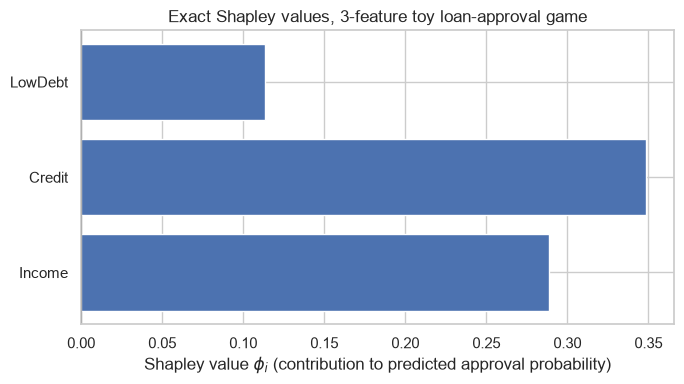

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4C72B0" if val >= 0 else "#C44E52" for val in phi.values()]
ax.barh(list(phi.keys()), list(phi.values()), color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Shapley value $\\phi_i$ (contribution to predicted approval probability)")
ax.set_title("Exact Shapley values, 3-feature toy loan-approval game")
plt.tight_layout()
plt.show()

## 3. Implementation: explaining a real income-prediction model

We now move to a real dataset, a real model, and the real `shap` and
`lime` libraries.

**Dataset: UCI Adult / Census Income.** Extracted from the 1994 US Census
database by Barry Becker, hosted at the UCI Machine Learning Repository.
Each row is one adult; the task is binary classification of whether their
annual income exceeds \$50K, from demographic and employment features
(age, education, occupation, hours worked, marital status, capital
gain/loss, etc.). It is one of the most widely used tabular benchmarks in
the fairness/explainability literature specifically because income
prediction is a real, regulated, high-stakes use case (credit, lending,
and insurance underwriting models are legally required in many
jurisdictions to support individual adverse-action explanations) and
because it contains protected-adjacent attributes (`sex`, `race`,
`native-country`) whose interactions with other features are exactly what
local explanations are used to probe. **Known issues**: the data is from
1994, US-only, and — as with COMPAS — reflects the demographic and economic
patterns of its era (e.g. `sex` is binary-coded and `marital-status`/
`relationship` fields encode dated household-structure assumptions); it
should not be read as a template for a real-world deployed income model,
only as a realistic-enough sandbox for explanation methods.

In [3]:
import pandas as pd
import numpy as np

COLS = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country",
    "income",
]
ADULT_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
)
raw = pd.read_csv(ADULT_URL, header=None, names=COLS, na_values=" ?", skipinitialspace=True)
raw = raw.dropna().reset_index(drop=True)
print(raw.shape)
raw.head()

(32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = raw.copy()
df["target"] = (df["income"].str.strip() == ">50K").astype(int)
df = df.drop(columns=["income", "fnlwgt"])  # fnlwgt is a census sampling weight, not a predictive feature

categorical_cols = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country",
]
numeric_cols = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]

encoders = {}
for c in categorical_cols:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c].astype(str))
    encoders[c] = le

feature_cols = numeric_cols + categorical_cols
X = df[feature_cols]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"train: {X_train.shape}, test: {X_test.shape}")
print(f"base rate (P(income > 50K)) overall: {y.mean():.3f}")

train: (26048, 13), test: (6513, 13)
base rate (P(income > 50K)) overall: 0.241


### 3.1 Training a gradient-boosted-tree model

We use `xgboost`, the standard practitioner choice for tabular
classification and the model class TreeSHAP was specifically designed for
(exact, polynomial-time Shapley values on tree ensembles).

In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
)
model.fit(X_train, y_train)

pred_proba = model.predict_proba(X_test)[:, 1]
pred = model.predict(X_test)

auc = roc_auc_score(y_test, pred_proba)
acc = accuracy_score(y_test, pred)
print(f"Test AUC      : {auc:.4f}")
print(f"Test accuracy : {acc:.4f}")
print()
print(classification_report(y_test, pred, target_names=["<=50K", ">50K"]))

Test AUC      : 0.9312
Test accuracy : 0.8782

              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      4945
        >50K       0.79      0.68      0.73      1568

    accuracy                           0.88      6513
   macro avg       0.84      0.81      0.83      6513
weighted avg       0.87      0.88      0.88      6513



### 3.2 Global explanation with SHAP (TreeExplainer)

`shap.TreeExplainer` runs the exact TreeSHAP algorithm on the fitted
XGBoost model. We compute SHAP values for every test-set row, which lets us
build both instance-level explanations and a global importance summary
(via the additivity axiom — Section 1.5 — per-instance SHAP values can be
honestly aggregated).

In [6]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

print("SHAP values shape:", shap_values.values.shape)
print("Expected value (phi_0, i.e. E[f(X)] over training background):", explainer.expected_value)
print("Model's mean predicted probability on test set             :", pred_proba.mean())

SHAP values shape: (6513, 13)
Expected value (phi_0, i.e. E[f(X)] over training background): -1.1918341
Model's mean predicted probability on test set             : 0.24210526


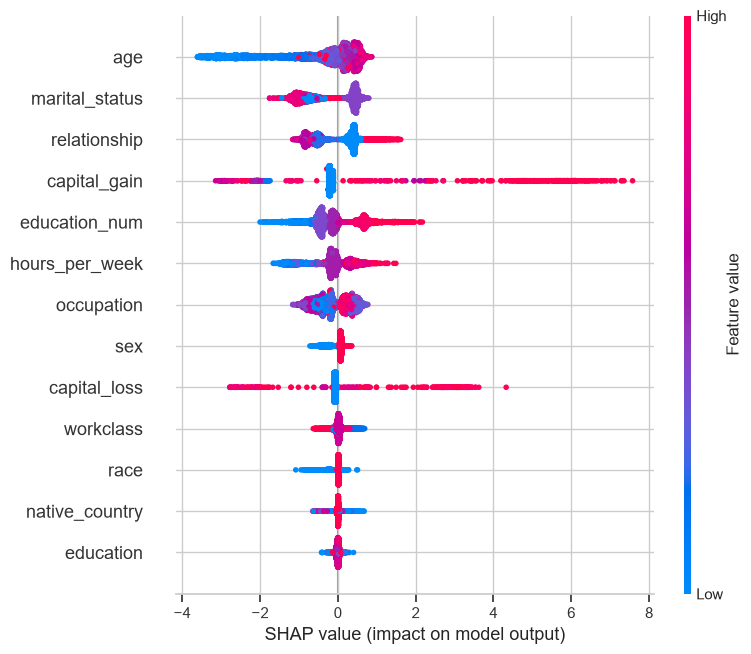

In [7]:
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

This **beeswarm summary plot** is the global view: each point is one
(instance, feature) SHAP value, features are ranked by mean absolute SHAP
value (overall importance), color encodes the feature's raw value
(red = high, blue = low). Let's read off the exact numeric ranking rather
than relying on the plot alone.

In [8]:
mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=feature_cols
).sort_values(ascending=False)
mean_abs_shap

age               0.749856
marital_status    0.684720
relationship      0.557565
capital_gain      0.515365
education_num     0.492677
hours_per_week    0.390809
occupation        0.388908
sex               0.159239
capital_loss      0.156206
workclass         0.080185
race              0.049731
native_country    0.035026
education         0.034050
dtype: float32

### 3.3 Explaining one individual prediction: SHAP waterfall

Now we zoom in on a single prediction. We pick one test-set individual and
show exactly how their features push the model's baseline output up or
down to their final predicted probability — the local accuracy property
from Section 1.3 guarantees this decomposition sums exactly to $f(x)$.

In [9]:
idx = int(np.argmax(pred_proba[:200]))  # a confidently-predicted-high-income individual within the first 200 test rows
instance = X_test.iloc[idx]
print("Predicted P(income > 50K):", pred_proba[idx])
print()
print(instance)

Predicted P(income > 50K): 0.9990532

age                  44
education_num        15
capital_gain      15024
capital_loss          0
hours_per_week       75
workclass             7
education            14
marital_status        2
occupation           10
relationship          0
race                  4
sex                   1
native_country       39
Name: 22969, dtype: int64


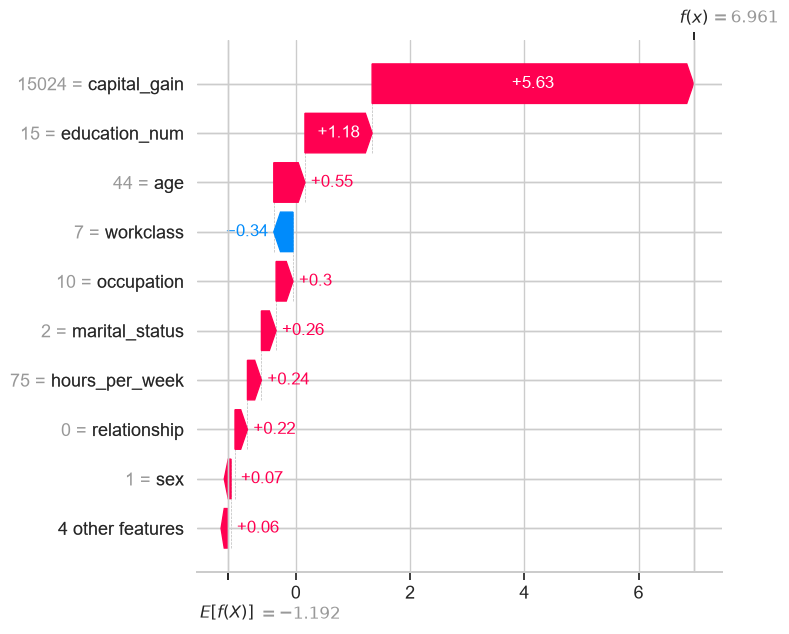

In [10]:
shap.plots.waterfall(shap_values[idx], show=False)
plt.tight_layout()
plt.show()

In [11]:
manual_sum = explainer.expected_value + shap_values.values[idx].sum()
print(f"phi_0 + sum(phi_i) for this instance : {manual_sum:.6f}")
print(f"model's raw margin output f(x)       : {shap_values.base_values[idx] + shap_values.values[idx].sum():.6f}")
print(f"model predict_proba(x)[1]            : {pred_proba[idx]:.6f}")

phi_0 + sum(phi_i) for this instance : 6.961442
model's raw margin output f(x)       : 6.961442
model predict_proba(x)[1]            : 0.999053


Note the SHAP values above are computed on the model's raw **margin**
output (log-odds), not the post-sigmoid probability — this is standard for
`TreeExplainer` on a probabilistic classifier, and is exactly why "local
accuracy" needs to be checked against the *margin* sum rather than the
probability directly. This is a common practitioner trip-up: SHAP force
plots are additive in log-odds space, not probability space, since the
sigmoid transform is nonlinear and would break the efficiency axiom if
applied per-feature.

### 3.4 Explaining the same individual with LIME

`lime.lime_tabular.LimeTabularExplainer` perturbs this instance's feature
values, weights the perturbations by proximity (Section 1.4), and fits a
local linear surrogate. We explain the *same* individual as above so we can
directly compare SHAP's and LIME's attributions for one prediction.

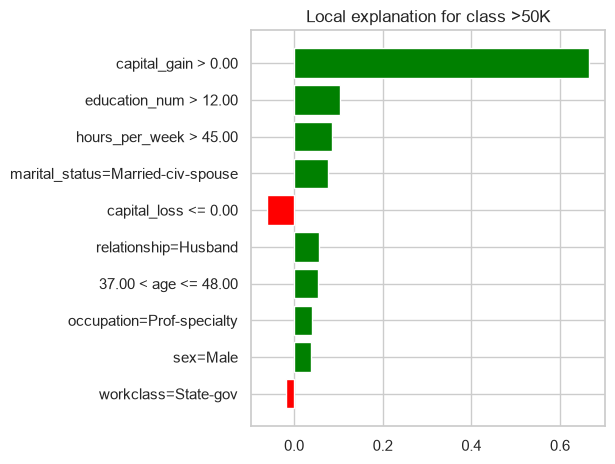

In [12]:
from lime.lime_tabular import LimeTabularExplainer

categorical_feature_idx = [feature_cols.index(c) for c in categorical_cols]
categorical_names = {
    feature_cols.index(c): list(encoders[c].classes_) for c in categorical_cols
}

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_cols,
    class_names=["<=50K", ">50K"],
    categorical_features=categorical_feature_idx,
    categorical_names=categorical_names,
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

lime_exp = lime_explainer.explain_instance(
    X_test.iloc[idx].values,
    model.predict_proba,
    num_features=10,
)
lime_exp.show_in_notebook = None  # not usable outside a live kernel widget context; use as_pyplot_figure instead
fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

In [13]:
print(f"LIME local surrogate intercept: {lime_exp.intercept[1]:.4f}")
print(f"LIME local surrogate R^2 (fidelity to f in this neighborhood): {lime_exp.score:.4f}")
print()
print("LIME feature-condition -> weight (class '>50K'):")
for cond, weight in lime_exp.as_list():
    print(f"  {cond:45s} {weight:+.4f}")

LIME local surrogate intercept: 0.0102
LIME local surrogate R^2 (fidelity to f in this neighborhood): 0.6640

LIME feature-condition -> weight (class '>50K'):
  capital_gain > 0.00                           +0.6655
  education_num > 12.00                         +0.1040
  hours_per_week > 45.00                        +0.0850
  marital_status=Married-civ-spouse             +0.0765
  capital_loss <= 0.00                          -0.0604
  relationship=Husband                          +0.0566
  37.00 < age <= 48.00                          +0.0533
  occupation=Prof-specialty                     +0.0405
  sex=Male                                      +0.0380
  workclass=State-gov                           -0.0172


### 3.5 SHAP vs. LIME on the same prediction

LIME's surrogate operates on discretized/binned conditions
(`as_list()` returns human-readable thresholds, e.g. `"capital_gain > X"`)
rather than SHAP's raw per-feature attributions, so a direct numeric
comparison requires mapping LIME's binned conditions back to their
underlying features. We compare which *features* each method ranks as most
influential for this individual.

In [14]:
shap_ranking = pd.Series(
    shap_values.values[idx], index=feature_cols
).abs().sort_values(ascending=False)

# crude feature-name extraction from LIME's condition strings, e.g.
# "capital_gain > 5013.00" -> "capital_gain"
def extract_feature(cond):
    for f in feature_cols:
        if cond.startswith(f):
            return f
    return cond

lime_ranking = pd.Series(
    {extract_feature(c): abs(w) for c, w in lime_exp.as_list()}
).sort_values(ascending=False)

comparison = pd.DataFrame({
    "SHAP |phi_i| rank": shap_ranking.rank(ascending=False),
    "LIME |weight| rank": lime_ranking.reindex(shap_ranking.index).rank(ascending=False),
}).sort_values("SHAP |phi_i| rank")
comparison

,SHAP |phi_i| rank,LIME |weight| rank
capital_gain,1.0,1.0
education_num,2.0,2.0
age,3.0,NaN
workclass,4.0,9.0
occupation,5.0,7.0
marital_status,6.0,4.0
hours_per_week,7.0,3.0
relationship,8.0,6.0
sex,9.0,8.0
education,10.0,NaN


In [15]:
from scipy.stats import spearmanr

common = comparison.dropna()
rho, p = spearmanr(common["SHAP |phi_i| rank"], common["LIME |weight| rank"])
print(f"Spearman rank correlation between SHAP and LIME feature importance rankings: rho = {rho:.3f} (p = {p:.4f})")

Spearman rank correlation between SHAP and LIME feature importance rankings: rho = 0.400 (p = 0.2861)


### 3.6 LIME's explanation stability across repeated runs

Because LIME's explanation depends on a *sampled* perturbation neighborhood
(Section 1.4), running it again on the exact same instance with the exact
same trained model but a different random seed does not, in general, give
the exact same coefficients. We rerun LIME 10 times on the same instance
with different random seeds and measure how much the attribution for the
top feature moves.

In [16]:
import re

def lime_weight_for(feature_name, num_runs=10, num_samples=5000):
    weights = []
    for seed in range(num_runs):
        # A fresh explainer per seed varies the perturbation sampling stream,
        # isolating explanation-sampling randomness (Section 1.4) as the only
        # thing that changes run-to-run -- same model, same instance, same config.
        seeded_explainer = LimeTabularExplainer(
            training_data=X_train.values,
            feature_names=feature_cols,
            class_names=["<=50K", ">50K"],
            categorical_features=categorical_feature_idx,
            categorical_names=categorical_names,
            mode="classification",
            discretize_continuous=True,
            random_state=seed,
        )
        exp = seeded_explainer.explain_instance(
            X_test.iloc[idx].values,
            model.predict_proba,
            num_features=10,
            num_samples=num_samples,
        )
        d = {extract_feature(c): w for c, w in exp.as_list()}
        weights.append(d.get(feature_name, 0.0))
    return np.array(weights)

top_feature = shap_ranking.index[0]
run_weights = lime_weight_for(top_feature)

print(f"Feature examined: '{top_feature}' (SHAP's top-ranked feature for this instance)")
print("LIME weight across 10 independent runs (num_samples=5000 each):")
print(np.round(run_weights, 4))
print(f"\nmean   = {run_weights.mean():.4f}")
print(f"std    = {run_weights.std():.4f}")
print(f"range  = {run_weights.max() - run_weights.min():.4f}")
print(f"relative std (std / |mean|) = {run_weights.std() / abs(run_weights.mean()):.2%}")

Feature examined: 'capital_gain' (SHAP's top-ranked feature for this instance)
LIME weight across 10 independent runs (num_samples=5000 each):
[0.6697 0.6697 0.6651 0.6689 0.6873 0.6774 0.6642 0.652  0.7053 0.6716]

mean   = 0.6731
std    = 0.0137
range  = 0.0533
relative std (std / |mean|) = 2.04%


This directly demonstrates the instability discussed formally in Section 6:
the *same* model, the *same* instance, and the *same* LIME configuration
produce a non-trivial spread in the reported attribution purely from
perturbation-sampling randomness — a property SHAP's TreeSHAP computation
does not have (TreeSHAP is exact and deterministic given the same model and
background data).

## 4. Use cases

- **Credit/loan adverse-action notices.** US Regulation B (ECOA) requires
  lenders to give applicants specific, principal reasons for a credit
  denial. SHAP or LIME attributions on a denied application are commonly
  used to generate the human-readable "top reasons" text, though regulators
  have not endorsed either method as sufficient on its own (Section 6).
- **Clinical risk-score review.** Hospital deployment of ML risk scores
  (e.g. sepsis or readmission risk) increasingly requires a clinician-facing
  explanation per patient before the score is acted on; SHAP force/waterfall
  plots are a common interface for this, letting a clinician sanity-check
  whether the top contributing factors are clinically plausible.
- **Model debugging and feature-engineering audits.** SHAP summary plots
  are widely used during model development, before any deployment, to spot
  a feature with surprising sign/magnitude of contribution (e.g. a proxy
  variable that shouldn't be predictive but is, indicating leakage) — this
  is a "look at the whole model" global use, distinct from the per-instance
  explanation use case.
- **Content moderation / fraud-flag review queues.** When an automated
  system flags a transaction or post for human review, a local explanation
  (often LIME, for its simplicity in non-tabular domains like text) is
  frequently surfaced to the human reviewer to speed up their decision,
  though this creates exactly the "explanation as a nudge toward agreement"
  risk discussed below.

## 5. Limitations & debates

- **SHAP's guarantees rely on a choice of "missing feature" semantics that
  breaks down under correlated features.** The value function
  $v(S) = \mathbb{E}[f(X) \mid X_S = x_S]$ (Section 1.3) requires
  marginalizing over the *true conditional* distribution of the absent
  features given the present ones. In practice, KernelSHAP and even
  TreeSHAP's default ("interventional" vs. "tree path dependent")
  implementations often instead sample/marginalize the absent features as
  if they were *independent* of the present ones. When features are
  strongly correlated (e.g. `education` and `education_num` in this
  dataset, or `age` and `marital_status`), this produces attributions to
  "impossible" or off-manifold combinations (e.g. crediting `education_num`
  for a value combination that never co-occurs with the specific
  `education` category in the real data), and the same total effect can be
  redistributed differently depending on this implementation choice. Kumar,
  Venkatasubramanian, Scheidegger & Friedler (2020), *"Problems with
  Shapley-value-based explanations as feature importance measures,"*
  formalize this and several other critiques, arguing Shapley values were
  designed for *payoff allocation* in games with well-defined, independent
  players, and the axioms that make them attractive for that purpose (e.g.
  symmetry) do not straightforwardly justify their use as a *causal or
  even purely statistical* feature-importance measure when real-world
  features are entangled.
- **LIME's explanation is sensitive to the kernel width $\sigma$ and the
  perturbation sampling scheme, with no principled default.** Section 1.4's
  objective requires choosing $\sigma$ (how "local" is local) and a
  sampling distribution for perturbed points; both are heuristic choices in
  the reference implementation (e.g. Gaussian perturbation of continuous
  features around their training-data statistics, not around $x$ itself).
  Alvarez-Melis & Jaakkola (2018), *"On the Robustness of Interpretability
  Methods,"* and related work document that small changes in $\sigma$ or
  simply re-running LIME with a different random seed can produce
  materially different, sometimes contradictory, top-feature rankings for
  the *identical* prediction — exactly the effect we measured directly in
  Section 3.6. A method whose output changes noticeably under a fixed
  input and a fixed model, purely from internal randomness, is a weak
  basis for a high-stakes individual explanation unless that variance is
  explicitly reported alongside the explanation (which most tooling and
  most deployments do not do).
- **Neither method has been established by regulators as legally
  sufficient for a "right to explanation."** GDPR Article 22 restricts
  fully automated decisions with legal or similarly significant effects and
  is often read (Recital 71, though its binding force is legally disputed)
  as implying a right to "meaningful information about the logic involved."
  SHAP and LIME attributions are commonly deployed *as if* they satisfy
  this, but neither method: (a) is causal — a SHAP or LIME attribution
  describes correlational contribution to the model's output, not "if this
  feature were different, the real-world outcome would change"; (b)
  explains the underlying decision *process* — both explain one trained
  model's behavior at one point, not the institution's overall decision
  policy; or (c) is guaranteed stable/reproducible for LIME, as shown above
  — an explanation that would come out differently on a re-run is a
  questionable basis for a legal disclosure obligation. Legal scholars
  (e.g. Wachter, Mittelstadt & Floridi 2017, on the GDPR "right to
  explanation" debate) have argued the regulatory text is itself ambiguous
  about whether any post-hoc local explanation method actually discharges
  this obligation.
- **A crisp local explanation can create false confidence about a globally
  complex, possibly unstable model.** A SHAP waterfall or LIME bar plot
  presents a clean, additive-looking story ("age contributed +0.3,
  capital_gain contributed +0.5, ..."), which can read as more mechanistic
  and trustworthy than it is. Both methods explain the *model's* behavior,
  not the world's — if the model itself is overfit, miscalibrated, or
  relying on a spurious correlation, the explanation will faithfully
  describe that spurious reasoning in a format that looks authoritative.
  Practitioners and downstream reviewers (loan officers, clinicians,
  moderators) can anchor on a plausible-looking local explanation instead
  of asking the harder, un-answered question: is the model's overall
  decision boundary appropriate in the first place? Local explainability
  is not a substitute for global model validation, calibration checks,
  or a held-out evaluation of the model's actual error modes.
- **SHAP's TreeSHAP and KernelSHAP results are also not identical to each
  other on the same model**, since they use different feature-marginalization
  strategies (path-dependent vs. interventional). Practitioners sometimes
  treat "SHAP value" as a single well-defined number for a given
  (model, instance, feature) triple; it is actually a family of related but
  distinct quantities depending on the algorithm and its configuration.

## References

- Shapley, L. S. (1953). *A Value for n-Person Games*. Contributions to the
  Theory of Games, 2(28).
- Lundberg, S. M., & Lee, S.-I. (2017). *A Unified Approach to Interpreting
  Model Predictions*. NeurIPS.
- Lundberg, S. M., Erion, G., Chen, H., et al. (2020). *From Local
  Explanations to Global Understanding with Explainable AI for Trees*.
  Nature Machine Intelligence, 2(1).
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *"Why Should I Trust
  You?": Explaining the Predictions of Any Classifier*. KDD.
- Kumar, I. E., Venkatasubramanian, S., Scheidegger, C., & Friedler, S.
  (2020). *Problems with Shapley-value-based explanations as feature
  importance measures*. ICML.
- Alvarez-Melis, D., & Jaakkola, T. S. (2018). *On the Robustness of
  Interpretability Methods*. arXiv:1806.08049 / WHI Workshop, ICML.
- Wachter, S., Mittelstadt, B., & Floridi, L. (2017). *Why a Right to
  Explanation of Automated Decision-Making Does Not Exist in the General
  Data Protection Regulation*. International Data Privacy Law, 7(2).
- Kohavi, R., & Becker, B. (1996). *UCI Adult / Census Income Data Set*.
  UCI Machine Learning Repository.
- [SHAP documentation](https://shap.readthedocs.io)
- [LIME documentation / repository](https://github.com/marcotcr/lime)
- Regulation B (ECOA), 12 CFR Part 1002 — adverse action notice
  requirements.
- GDPR, Article 22 and Recital 71 — automated individual decision-making.